# FPbase sequence-identity alignment & clustering

Compute **true pairwise % identity** with Biopython's `PairwiseAligner` (global Needleman-Wunsch by
default), then **single-linkage cluster** the FPs so whole families can be held out together in a
train/test split. After the threshold sweep, the lower blocks let you **see how the identity threshold
reshapes the cluster-size distribution** (slider + static views), so you can pick a threshold deliberately.

Outputs (next to the dataset): `identity_matrix.npy` (N x N) and `clusters.csv` (per-row cluster id).

## 0. Setup & knobs

In [1]:
import csv, os, time, json
from collections import defaultdict
import numpy as np
from Bio import Align
from Bio.Align import substitution_matrices

try:
    import matplotlib.pyplot as plt
    HAVE_PLT = True
except Exception:
    HAVE_PLT = False

DATA_DIR = os.path.join("..", "fpbase-extractor", "processed_data", "ESM-spectrum")

# ---- tuning knobs (change, then re-run the matrix cell) ----
MODE         = "global"     # "global" (Needleman-Wunsch) or "local" (Smith-Waterman)
MATRIX       = "BLOSUM62"
GAP_OPEN     = 11.0
GAP_EXTEND   = 1.0
IDENTITY_DEN = "shorter"    # "shorter" (matches / shorter seq) or "alignment" (/ aln length)
MIN_COVERAGE = 0.8          # ignore identity from overlaps smaller than this fraction of shorter seq
PREFILTER    = 0.2          # skip aligning pairs with k-mer containment below this (speed); 0 = align all
KMER         = 3
LIMIT        = 0            # 0 = all rows; >0 for a quick debug subset
print("data dir:", os.path.abspath(DATA_DIR))

data dir: /Users/zhengqing/PyProjects/fpbase-extractor/processed_data/ESM-spectrum


## 1. Load sequences (collapse exact duplicates)

In [2]:
rows = list(csv.DictReader(open(os.path.join(DATA_DIR, "metadata.csv"))))
if LIMIT:
    rows = rows[:LIMIT]
seqs = [r["seq"].strip().upper() for r in rows]
N = len(rows)

uniq = {}; uidx = []
for s in seqs:
    uidx.append(uniq.setdefault(s, len(uniq)))
uniq_seqs = [None] * len(uniq)
for s, u in uniq.items():
    uniq_seqs[u] = s
uidx = np.array(uidx)
print(f"{N} rows | {len(uniq_seqs)} unique sequences ({N-len(uniq_seqs)} exact duplicates collapsed)")

453 rows | 430 unique sequences (23 exact duplicates collapsed)


## 2. Alignment & clustering functions

In [3]:
def kmer_containment(seqs, k):
    vocab = {}; per = []
    for s in seqs:
        kms = {s[i:i+k] for i in range(len(s)-k+1)}
        per.append([vocab.setdefault(m, len(vocab)) for m in kms])
    P = np.zeros((len(seqs), len(vocab)), dtype=np.float32)
    for i, idx in enumerate(per):
        P[i, idx] = 1.0
    C = (P @ P.T) / np.maximum(np.minimum.outer(P.sum(1), P.sum(1)), 1.0)
    np.fill_diagonal(C, 1.0)
    return C


def make_aligner():
    a = Align.PairwiseAligner()
    a.mode = MODE
    a.substitution_matrix = substitution_matrices.load(MATRIX)
    a.open_gap_score = -abs(GAP_OPEN)
    a.extend_gap_score = -abs(GAP_EXTEND)
    return a


def pair_identity(aligner, a, b):
    aln = aligner.align(a, b)[0]
    c = aln.counts()                       # .identities, .mismatches, .gaps
    aligned = c.identities + c.mismatches
    shorter = min(len(a), len(b))
    if shorter == 0 or aligned / shorter < MIN_COVERAGE:
        return 0.0
    d = shorter if IDENTITY_DEN == "shorter" else aln.length
    return c.identities / d if d else 0.0


def identity_matrix(seqs, log_every=4000):
    n = len(seqs)
    M = np.eye(n, dtype=np.float32)
    aligner = make_aligner()
    C = kmer_containment(seqs, KMER) if PREFILTER > 0 else None
    pairs = [(i, j) for i in range(n) for j in range(i+1, n)
             if C is None or C[i, j] >= PREFILTER]
    print(f"aligning {len(pairs)} / {n*(n-1)//2} pairs (prefilter skipped {n*(n-1)//2 - len(pairs)})")
    t = time.time()
    for done, (i, j) in enumerate(pairs, 1):
        M[i, j] = M[j, i] = pair_identity(aligner, seqs[i], seqs[j])
        if done % log_every == 0:
            print(f"  {done}/{len(pairs)} ({done/(time.time()-t):.0f}/s)")
    print(f"done in {time.time()-t:.1f}s")
    return M


def single_linkage(M, thr):
    n = len(M); parent = list(range(n))
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x
    for i, j in np.argwhere(np.triu(M >= thr, 1)):
        ri, rj = find(int(i)), find(int(j))
        if ri != rj: parent[ri] = rj
    comp = defaultdict(list)
    for i in range(n): comp[find(i)].append(i)
    return sorted(comp.values(), key=len, reverse=True)

## 3. Compute (or load) the identity matrix

Aligns unique sequences, expands to full N x N, and **caches the result**. On restart it **loads the cache
instantly** as long as the alignment knobs (§0) and the sequences are unchanged; if you change any knob it
**recomputes automatically** (the cache stores a fingerprint of the knobs + sequences, so it can't load a
stale matrix). Set `FORCE_RECOMPUTE = True` to rebuild regardless.

Cached to `identity_matrix.npy` (+ `identity_matrix.meta.json` fingerprint) next to the dataset.

In [4]:
import hashlib

FORCE_RECOMPUTE = False   # set True to ignore the cache and rebuild

mat_path  = os.path.join(DATA_DIR, "identity_matrix.npy")
meta_path = os.path.join(DATA_DIR, "identity_matrix.meta.json")

def _signature():
    seq_md5 = hashlib.md5("\x00".join(uniq_seqs).encode()).hexdigest()
    return {"mode": MODE, "matrix": MATRIX, "gap_open": GAP_OPEN, "gap_extend": GAP_EXTEND,
            "identity_den": IDENTITY_DEN, "min_coverage": MIN_COVERAGE,
            "prefilter": PREFILTER, "kmer": KMER,
            "n_rows": N, "n_unique": len(uniq_seqs), "seq_md5": seq_md5}

sig = _signature()
cache_ok = (not FORCE_RECOMPUTE and os.path.exists(mat_path) and os.path.exists(meta_path)
            and json.load(open(meta_path)) == sig)

if cache_ok:
    M = np.load(mat_path)
    print(f"loaded cached identity matrix {M.shape} (knobs + sequences unchanged) -> {mat_path}")
else:
    if FORCE_RECOMPUTE:
        why = "forced recompute"
    elif not os.path.exists(meta_path):
        why = "no cache yet"
    else:
        why = "knobs or sequences changed -> cache invalidated"
    print(f"computing identity matrix ({why}) ...")
    Mu = identity_matrix(uniq_seqs)
    M = Mu[np.ix_(uidx, uidx)].copy()
    np.fill_diagonal(M, 1.0)
    np.save(mat_path, M)
    json.dump(sig, open(meta_path, "w"), indent=1)
    print(f"cached identity matrix {M.shape} -> {mat_path}")

loaded cached identity matrix (453, 453) (knobs + sequences unchanged) -> ../fpbase-extractor/processed_data/ESM-spectrum/identity_matrix.npy


## 4. Threshold sweep

id>=0.30:  22 clusters | largest 220 ( 49% of data) | singletons   8
id>=0.35:  22 clusters | largest 220 ( 49% of data) | singletons   8
id>=0.40:  22 clusters | largest 220 ( 49% of data) | singletons   8
id>=0.45:  22 clusters | largest 220 ( 49% of data) | singletons   8
id>=0.50:  22 clusters | largest 220 ( 49% of data) | singletons   8
id>=0.55:  22 clusters | largest 220 ( 49% of data) | singletons   8
id>=0.60:  29 clusters | largest 198 ( 44% of data) | singletons  11
id>=0.65:  39 clusters | largest 181 ( 40% of data) | singletons  16
id>=0.70:  46 clusters | largest 165 ( 36% of data) | singletons  18
id>=0.75:  49 clusters | largest 165 ( 36% of data) | singletons  20
id>=0.80:  54 clusters | largest 165 ( 36% of data) | singletons  24


id>=0.85:  66 clusters | largest 159 ( 35% of data) | singletons  29
id>=0.90:  77 clusters | largest 159 ( 35% of data) | singletons  36


id>=0.95: 114 clusters | largest 149 ( 33% of data) | singletons  62
id>=1.00: 423 clusters | largest   3 (  1% of data) | singletons 395


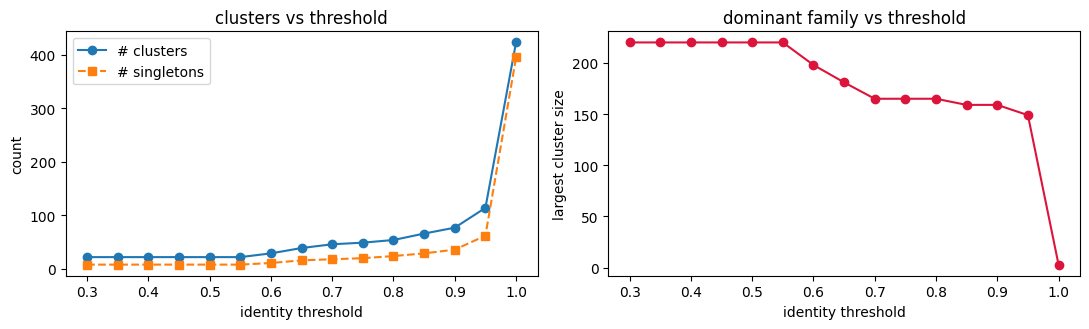

In [5]:
GRID = np.round(np.arange(0.30, 1.001, 0.05), 2)

def stats_at(thr):
    cl = single_linkage(M, thr)
    sizes = np.array([len(c) for c in cl])
    return cl, sizes

sweep = []
for thr in GRID:
    _, sizes = stats_at(thr)
    sweep.append((thr, len(sizes), int(sizes.max()), int((sizes == 1).sum()), sizes.max()/N))
    print(f"id>={thr:.2f}: {len(sizes):3d} clusters | largest {sizes.max():3d} "
          f"({sizes.max()/N:4.0%} of data) | singletons {(sizes==1).sum():3d}")
sweep = np.array(sweep)

if HAVE_PLT:
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    ax[0].plot(sweep[:,0], sweep[:,1], "o-", label="# clusters")
    ax[0].plot(sweep[:,0], sweep[:,3], "s--", label="# singletons")
    ax[0].set_xlabel("identity threshold"); ax[0].set_ylabel("count"); ax[0].legend()
    ax[0].set_title("clusters vs threshold")
    ax[1].plot(sweep[:,0], sweep[:,2], "o-", color="crimson")
    ax[1].set_xlabel("identity threshold"); ax[1].set_ylabel("largest cluster size")
    ax[1].set_title("dominant family vs threshold")
    plt.tight_layout(); plt.show()

## 5. How the threshold reshapes the cluster-size distribution

Three complementary views of the same question — *as I raise the identity cutoff, how do cluster sizes
spread out?*

### 5a. Size-distribution histograms across thresholds (small multiples)

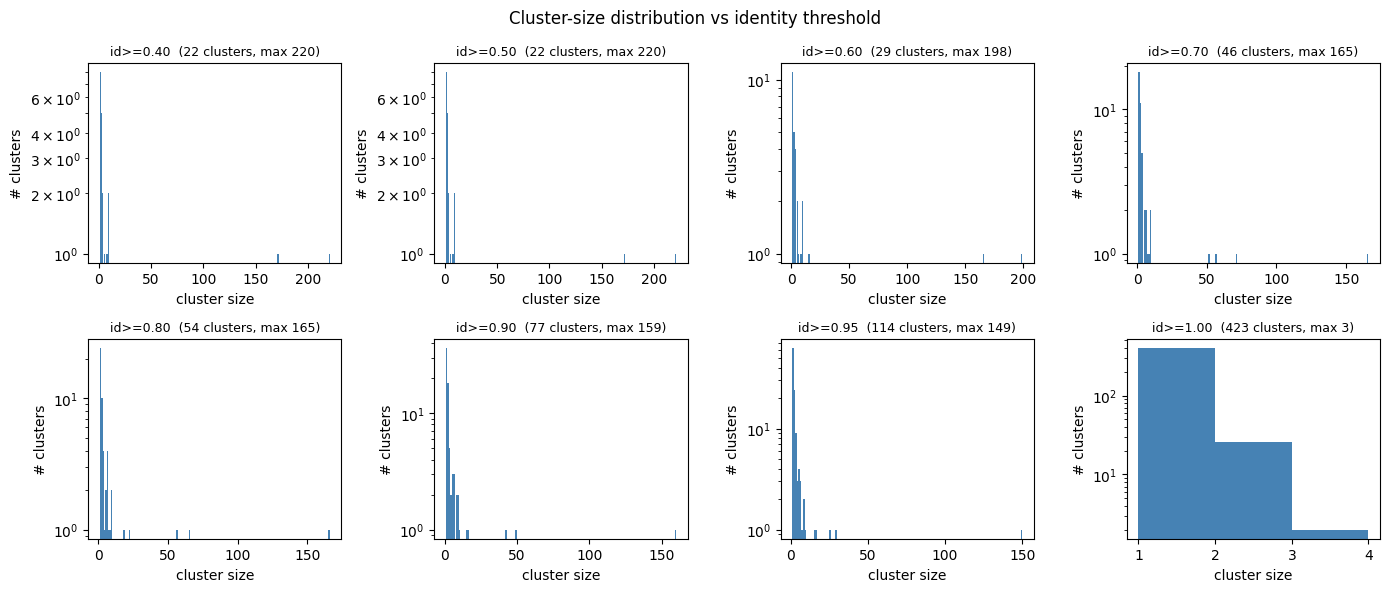

In [6]:
if HAVE_PLT:
    thrs = [0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 1.00]
    fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=False)
    for ax, thr in zip(axes.ravel(), thrs):
        _, sizes = stats_at(thr)
        ax.hist(sizes, bins=range(1, sizes.max()+2), color="steelblue")
        ax.set_yscale("log")
        ax.set_title(f"id>={thr:.2f}  ({len(sizes)} clusters, max {sizes.max()})", fontsize=9)
        ax.set_xlabel("cluster size"); ax.set_ylabel("# clusters")
    plt.suptitle("Cluster-size distribution vs identity threshold")
    plt.tight_layout(); plt.show()

### 5b. Where the sequences live (size-band composition)

For each threshold, what fraction of **sequences** sit in singletons vs small / medium / large clusters.
This shows the data migrating out of one giant family into many small clusters as the cutoff rises.

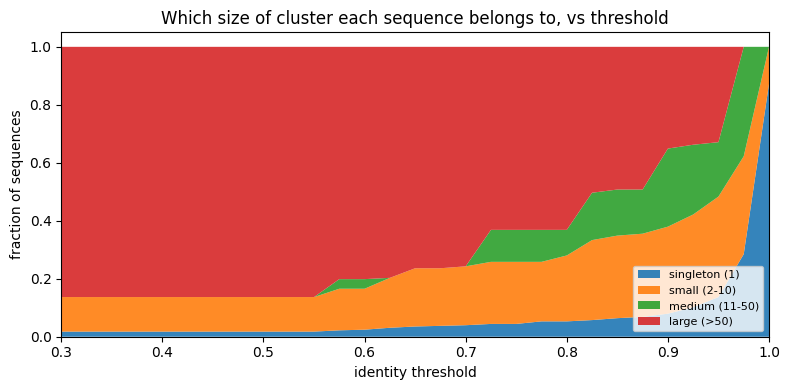

In [7]:
if HAVE_PLT:
    bands = [("singleton (1)", lambda s: s == 1),
             ("small (2-10)", lambda s: (s >= 2) & (s <= 10)),
             ("medium (11-50)", lambda s: (s >= 11) & (s <= 50)),
             ("large (>50)", lambda s: s > 50)]
    fine = np.round(np.arange(0.30, 1.001, 0.025), 3)
    comp = np.zeros((len(fine), len(bands)))
    for r, thr in enumerate(fine):
        _, sizes = stats_at(thr)
        per_seq = np.repeat(sizes, sizes)            # one entry per sequence = its cluster size
        for c, (_, f) in enumerate(bands):
            comp[r, c] = f(per_seq).sum() / per_seq.size
    plt.figure(figsize=(8, 4))
    plt.stackplot(fine, comp.T, labels=[b[0] for b in bands], alpha=0.9)
    plt.xlabel("identity threshold"); plt.ylabel("fraction of sequences")
    plt.title("Which size of cluster each sequence belongs to, vs threshold")
    plt.legend(loc="lower right", fontsize=8); plt.margins(x=0); plt.tight_layout(); plt.show()

### 5c. Rank-size curves (the long tail forming)

Sorted cluster sizes at several thresholds. The top point = the dominant family; as the threshold rises it
drops and the tail of small clusters lengthens.

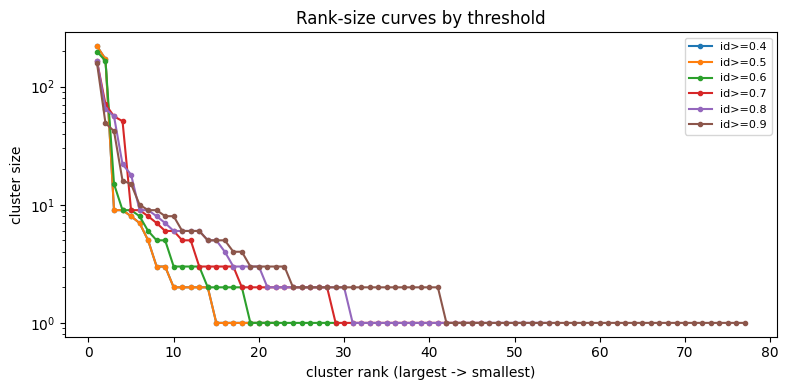

In [8]:
if HAVE_PLT:
    plt.figure(figsize=(8, 4))
    for thr in [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
        _, sizes = stats_at(thr)
        plt.plot(range(1, len(sizes)+1), sizes, marker=".", label=f"id>={thr}")
    plt.yscale("log"); plt.xlabel("cluster rank (largest -> smallest)")
    plt.ylabel("cluster size"); plt.title("Rank-size curves by threshold")
    plt.legend(fontsize=8); plt.tight_layout(); plt.show()

### 5d. Interactive: drag the threshold

In [9]:
def cluster_report(thr):
    cl, sizes = stats_at(thr)
    print(f"id>={thr:.2f}: {len(sizes)} clusters | largest {sizes.max()} "
          f"({sizes.max()/N:.0%} of data) | median {int(np.median(sizes))} | singletons {(sizes==1).sum()}")
    if HAVE_PLT:
        fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
        ax[0].hist(sizes, bins=range(1, sizes.max()+2), color="steelblue"); ax[0].set_yscale("log")
        ax[0].set_xlabel("cluster size"); ax[0].set_ylabel("# clusters"); ax[0].set_title("size histogram")
        ax[1].bar(range(1, min(len(sizes),20)+1), sizes[:20], color="indianred")
        ax[1].set_xlabel("rank"); ax[1].set_ylabel("size"); ax[1].set_title("top 20 clusters")
        plt.tight_layout(); plt.show()

try:
    from ipywidgets import interact, FloatSlider
    interact(cluster_report, thr=FloatSlider(min=0.3, max=1.0, step=0.05, value=0.7,
                                             description="identity"))
except Exception as e:
    print("ipywidgets unavailable; call cluster_report(thr) directly.", e)
    cluster_report(0.7)

interactive(children=(FloatSlider(value=0.7, description='identity', max=1.0, min=0.3, step=0.05), Output()), …

### 5e. Which proteins are in each cluster

List the member proteins of every cluster at a chosen threshold. `min_size` hides singletons; `max_members`
truncates big families. Members are sorted by emission so you can see the spectral spread within a family.

In [10]:
ex_max = np.array([float(r["ex_max"]) for r in rows])
em_max = np.array([float(r["em_max"]) for r in rows])


def list_clusters(thr, min_size=2, max_members=25):
    clusters = single_linkage(M, thr)
    shown = 0
    for cid, c in enumerate(clusters, 1):
        if len(c) < min_size:
            continue
        shown += 1
        members = sorted(c, key=lambda i: em_max[i])
        names = [rows[i]["name"] for i in members]
        body = ", ".join(names[:max_members])
        if len(names) > max_members:
            body += f"  ... +{len(names)-max_members} more"
        print(f"cluster {cid}  (n={len(c)}, ex {ex_max[c].min():.0f}-{ex_max[c].max():.0f}, "
              f"em {em_max[c].min():.0f}-{em_max[c].max():.0f} nm)\n  {body}")
    sing = sum(1 for c in clusters if len(c) == 1)
    print(f"\n[{shown} clusters with >= {min_size} members shown; {sing} singletons hidden]")


list_clusters(0.70, min_size=2)

cluster 1  (n=165, ex 343-519, em 414-538 nm)
  Sumire, Sirius, EBFP, P4, EBFP2, oxBFP, P4-3E, mKalama1, PS-CFP2, mTurquoise2, moxCerulean3, mTurquoise, Aquamarine, SCFP3A, mCerulean3, mJuniper, mECFP, mCerulean, Cerulean, CyPet, ECFP, TagCFP, CFP, htFuncLib_fast.1, htFuncLib_basic.4  ... +140 more
cluster 2  (n=71, ex 402-678, em 467-702 nm)
  mBlueberry2, GdT, mWatermelon, mBanana, sfOrange, E2-Orange, mOrange, mHoneydew, mOrange2, PSmOrange, dKeima570, LSSmOrange, tdimer2(12), tdTomato, dTomato, DsRed, GRvT, pHmScarlet, mTangerine, DsRed-Express, mScarlet3-S2, DsRed2, DsRed.M1, mCherry-XL, DsRed-Max  ... +46 more
cluster 3  (n=56, ex 399-611, em 454-681 nm)
  Electra2, mTagBFP2, Electra1, secBFP2, TagBFP, mRubyFT, TurboRFP, super-TagRFP, TagRFP, cgfTagRFP, TagRFP-T, FusionRed-MQV, CyRFP1, CyOFP1, mRuby3, mCRISPRed, mCyRFP1, PATagRFP, mRuby2, TurboFP602, rsFusionRed1, mRuby, LSS-mKate2, rsFusionRed2, rsFusionRed3  ... +31 more
cluster 4  (n=51, ex 454-583, em 485-606 nm)
  meleCFP, d

In [11]:
# Drag the threshold (and min size) to re-list cluster membership.
try:
    from ipywidgets import interact, FloatSlider, IntSlider
    interact(lambda thr, min_size: list_clusters(thr, min_size=min_size),
             thr=FloatSlider(min=0.30, max=1.0, step=0.05, value=0.70, description="identity"),
             min_size=IntSlider(min=1, max=10, value=2, description="min size"))
except Exception as e:
    print("ipywidgets unavailable; call list_clusters(thr, min_size=) directly.", e)

interactive(children=(FloatSlider(value=0.7, description='identity', max=1.0, min=0.3, step=0.05), IntSlider(v…

### 5f. Drill into one cluster

Full member table (name, slug, ex/em) for a chosen cluster rank at a chosen threshold.

In [12]:
def show_cluster(thr, rank=1):
    clusters = single_linkage(M, thr)
    if rank > len(clusters):
        print(f"only {len(clusters)} clusters at id>={thr}"); return
    c = sorted(clusters[rank-1], key=lambda i: em_max[i])
    print(f"cluster rank {rank} at id>={thr}: {len(c)} members\n")
    print(f"{'name':30s} {'slug':22s} {'ex':>5} {'em':>5}")
    for i in c:
        print(f"{rows[i]['name'][:29]:30s} {rows[i].get('slug','')[:21]:22s} "
              f"{ex_max[i]:5.0f} {em_max[i]:5.0f}")

show_cluster(0.70, rank=1)

cluster rank 1 at id>=0.7: 165 members

name                           slug                      ex    em
Sumire                         sumire                   343   414
Sirius                         sirius                   355   424
EBFP                           ebfp                     380   440
P4                             p4                       382   448
EBFP2                          ebfp2                    383   448
oxBFP                          oxbfp                    385   448
P4-3E                          p4-3e                    384   448
mKalama1                       mkalama1                 385   456
PS-CFP2                        ps-cfp2                  400   468
mTurquoise2                    mturquoise2              434   474
moxCerulean3                   moxcerulean3             434   474
mTurquoise                     mturquoise               434   474
Aquamarine                     aquamarine               430   474
SCFP3A                         scfp3

### 5g. Cross-cluster similarity across all thresholds (dendrogram)

The single-linkage **dendrogram** encodes every threshold at once: the height where two groups join = the
**identity at which they merge**. A horizontal cut at identity `t` reproduces the clustering at threshold `t`
— so reading the tree top-to-bottom shows how clusters share similarity as the cutoff changes. The
histogram on the right is the distribution of those merge identities (how related groups are when they fuse).

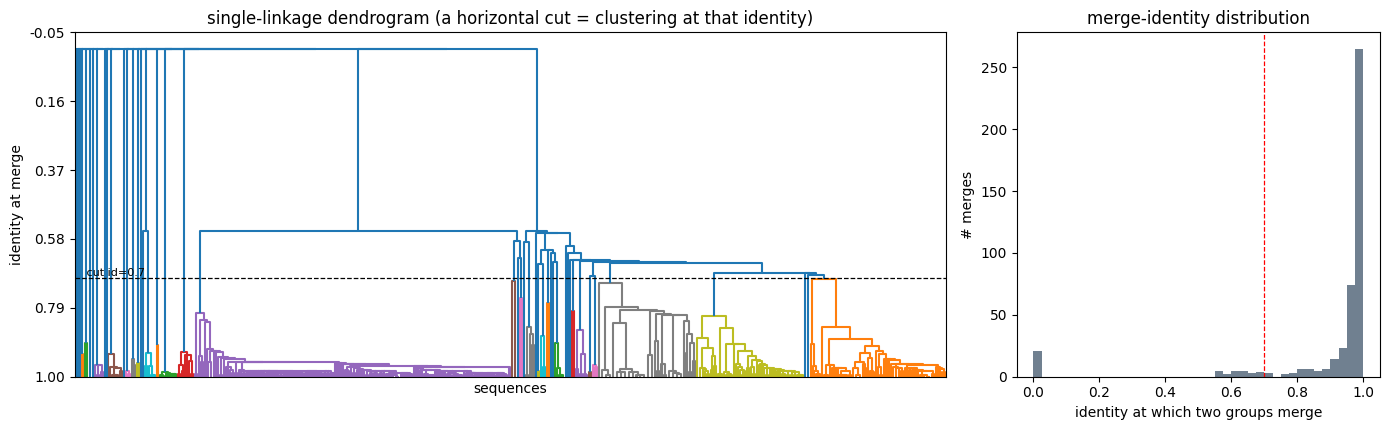

In [13]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

D = 1.0 - M
D = (D + D.T) / 2.0
np.fill_diagonal(D, 0.0)
Z = linkage(squareform(D, checks=False), method="single")   # merge distance = 1 - max cross identity

if HAVE_PLT:
    CUT = 0.70   # identity cut to color the clusters
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.4),
                           gridspec_kw={"width_ratios": [2.4, 1]})
    dendrogram(Z, no_labels=True, color_threshold=1 - CUT, ax=ax[0])
    ax[0].axhline(1 - CUT, color="k", ls="--", lw=0.9)
    ax[0].text(0.01, 1 - CUT, f" cut id={CUT}", color="k", va="bottom", fontsize=8,
               transform=ax[0].get_yaxis_transform())
    ticks = np.linspace(0, ax[0].get_ylim()[1], 6)
    ax[0].set_yticks(ticks); ax[0].set_yticklabels([f"{1-t:.2f}" for t in ticks])
    ax[0].set_ylabel("identity at merge"); ax[0].set_xlabel("sequences")
    ax[0].set_title("single-linkage dendrogram (a horizontal cut = clustering at that identity)")

    merge_id = 1 - Z[:, 2]
    ax[1].hist(merge_id, bins=40, color="slategray")
    ax[1].axvline(CUT, color="r", ls="--", lw=0.9)
    ax[1].set_xlabel("identity at which two groups merge"); ax[1].set_ylabel("# merges")
    ax[1].set_title("merge-identity distribution")
    plt.tight_layout(); plt.show()

### 5h. Between-cluster identity heatmap (at a chosen threshold)

For the clustering at a given threshold, how similar is each cluster to every *other* cluster. **Diagonal** =
within-cluster mean identity (cohesion); **off-diagonal** = max (or mean) cross-cluster identity — high
off-diagonal values flag families at risk of leaking across a train/test boundary. Clusters are labeled by a
representative member (medoid).

In [14]:
def between_cluster(thr=0.70, agg="max", min_size=3, annotate=True):
    cl = [c for c in single_linkage(M, thr) if len(c) >= min_size]
    K = len(cl)
    B = np.zeros((K, K))
    for a in range(K):
        for b in range(K):
            if a == b:
                w = M[np.ix_(cl[a], cl[a])][np.triu_indices(len(cl[a]), 1)]
                B[a, b] = w.mean() if w.size else 1.0
            else:
                sub = M[np.ix_(cl[a], cl[b])]
                B[a, b] = sub.max() if agg == "max" else sub.mean()
    labels = []
    for c in cl:
        medoid = max(c, key=lambda i: M[i, c].sum())     # most central member
        labels.append(f"{rows[medoid]['name'][:14]} (n={len(c)})")
    if HAVE_PLT:
        fig, ax = plt.subplots(figsize=(1.2 + 0.55*K, 1.0 + 0.55*K))
        im = ax.imshow(B, cmap="viridis", vmin=0, vmax=1)
        ax.set_xticks(range(K)); ax.set_xticklabels(labels, rotation=90, fontsize=7)
        ax.set_yticks(range(K)); ax.set_yticklabels(labels, fontsize=7)
        if annotate:
            for a in range(K):
                for b in range(K):
                    ax.text(b, a, f"{B[a,b]:.2f}", ha="center", va="center",
                            fontsize=6, color="white" if B[a,b] < 0.6 else "black")
        plt.colorbar(im, label=f"{agg} cross-cluster identity (diag = within-cluster mean)")
        ax.set_title(f"between-cluster identity  (id>={thr}, clusters n>={min_size})")
        plt.tight_layout(); plt.show()
    return B, labels

try:
    from ipywidgets import interact, FloatSlider, IntSlider, Dropdown, Checkbox
    interact(between_cluster,
             thr=FloatSlider(min=0.50, max=0.95, step=0.05, value=0.70, description="identity"),
             agg=Dropdown(options=["max", "mean"], value="max", description="aggregate"),
             min_size=IntSlider(min=1, max=10, value=3, description="min size"),
             annotate=Checkbox(value=True, description="annotate"))
except Exception as e:
    print("ipywidgets unavailable; call between_cluster(0.70) directly.", e)
    between_cluster(0.70)

interactive(children=(FloatSlider(value=0.7, description='identity', max=0.95, min=0.5, step=0.05), Dropdown(d…

## 6. Commit a clustering & write clusters.csv

In [15]:
THRESHOLD = 0.70   # <- your decision

clusters = single_linkage(M, THRESHOLD)
label = np.empty(N, dtype=int)
for cid, c in enumerate(clusters):
    for i in c:
        label[i] = cid
sizes = [len(c) for c in clusters]
print(f"THRESHOLD={THRESHOLD}: {len(clusters)} clusters | largest {max(sizes)} | singletons {sum(s==1 for s in sizes)}")
for rank, c in enumerate(clusters[:6], 1):
    names = [rows[i]["name"] for i in c]
    print(f"  cluster {rank} (n={len(c)}): {', '.join(names[:8])}{' ...' if len(names)>8 else ''}")

out = os.path.join(DATA_DIR, "clusters.csv")
with open(out, "w", newline="") as fh:
    w = csv.writer(fh)
    w.writerow(["index", "slug", "name", "seq_group", "cluster", "cluster_size"])
    for i, r in enumerate(rows):
        w.writerow([i, r.get("slug",""), r.get("name",""), r.get("seq_group",""),
                    int(label[i]), sizes[int(label[i])]])
print("wrote", out)

THRESHOLD=0.7: 46 clusters | largest 165 | singletons 18
  cluster 1 (n=165): htFuncLib_fast.2, htFuncLib_acid.5, PROSS-eGFP, htFuncLib_acid.4, htFuncLib_sf:bleach.1, rsEGFP, mGreenLantern, GFPmut3 ...
  cluster 2 (n=71): mBlueberry2, mScarlet3-H, mStrawberry, pHmScarlet, DsRed-Express2, mLychee, LSSmOrange, mScarlet-2A ...
  cluster 3 (n=56): Maroon0.1, Electra2, super-TagRFP, CyOFP1, Katushka, TagRFP675, rsFusionRed1, mNeptune2.5 ...
  cluster 4 (n=51): CGP, Dendra2, Dendra2, Kohinoor, mEosEM, mEosEM, Skylan-NS, rsFastLime ...
  cluster 5 (n=9): miniGFP1, phiLOV3, miniGFP2, BR1, miniSOG2, phiLOV2.1, SOPP3, miniSOG ...
  cluster 6 (n=9): iRFP720, mRhubarb719, miRFP680, iRFP682, mRhubarb720, miRFP720, miRFP713, iRFP713 ...
wrote ../fpbase-extractor/processed_data/ESM-spectrum/clusters.csv


## 7. Coordinated cluster-wise train/val/test splits (surrogate + oracle)

Two cluster-wise splits over the same data (whole clusters never span splits):

- **Surrogate**: 70 / 15 / 15  (train / val / test)
- **Oracle**: 70 / 10 / 20  (train / val / test)

Constraints:
1. the **biggest cluster sits in *train* for both** models;
2. the oracle's 20% **test = 10% drawn from surrogate-train clusters + 10% from surrogate-test clusters**, so
   the oracle is certified in both the surrogate-seen (ID) and surrogate-unseen (OOD) regimes.

Because clusters are atomic and lumpy, exact percentages aren't possible; targets are hit as closely as
subset-sum allows. Uses the `THRESHOLD` chosen in section 6.

In [16]:
SPLIT_SEED = 0
clusters = single_linkage(M, THRESHOLD)          # whole clusters = split units
K = len(clusters)
sizes = np.array([len(c) for c in clusters])
total = int(sizes.sum())
biggest = 0                                       # clusters are sorted largest-first

def assign_bins(cids, targets, forced=None, seed=0):
    """Greedy cluster->bin assignment approximating target fractions (largest-deficit-first)."""
    rng = np.random.default_rng(seed)
    cur = {b: 0 for b in targets}; tgt = {b: targets[b]*total for b in targets}; out = {}
    for cid, b in (forced or {}).items():
        out[cid] = b; cur[b] += sizes[cid]
    rest = [c for c in cids if c not in (forced or {})]
    rng.shuffle(rest); rest.sort(key=lambda c: -sizes[c])
    for cid in rest:
        b = max(targets, key=lambda bb: tgt[bb] - cur[bb]); out[cid] = b; cur[b] += sizes[cid]
    return out

def subset_to_target(pool, target):
    """Subset of `pool` whose size-sum is closest to `target` (subset-sum DP)."""
    reach = {0: []}
    for cid in pool:
        s = int(sizes[cid])
        for cur in sorted(reach, reverse=True):
            if cur + s not in reach:
                reach[cur + s] = reach[cur] + [cid]
    best = min(reach, key=lambda v: (abs(v - target), v))
    return reach[best], best

# --- surrogate 70/15/15, biggest -> train ---
sur = assign_bins(range(K), {"train": .70, "val": .15, "test": .15},
                  forced={biggest: "train"}, seed=SPLIT_SEED)
S_tr = [c for c in range(K) if sur[c] == "train" and c != biggest]
S_te = [c for c in range(K) if sur[c] == "test"]

# --- oracle test = 10% from surrogate-train + 10% from surrogate-test (subset-sum) ---
ot_tr, n_tr = subset_to_target(S_tr, 0.10 * total)
ot_te, n_te = subset_to_target(S_te, 0.10 * total)
O_test = set(ot_tr) | set(ot_te)
O_rem = [c for c in range(K) if c not in O_test]
ora = dict.fromkeys(O_test, "test")
ora.update(assign_bins(O_rem, {"train": .70, "val": .10}, forced={biggest: "train"}, seed=SPLIT_SEED + 3))

# --- expand to per-row labels ---
split_sur = np.empty(N, dtype=object); split_ora = np.empty(N, dtype=object)
clabel = np.empty(N, dtype=int)
for cid in range(K):
    for i in clusters[cid]:
        split_sur[i] = sur[cid]; split_ora[i] = ora[cid]; clabel[i] = cid

# --- verify ---
def frac(arr, v): return (arr == v).sum() / N
print("SURROGATE  train/val/test:",
      [f"{frac(split_sur, b):.0%}" for b in ("train", "val", "test")])
print("ORACLE     train/val/test:",
      [f"{frac(split_ora, b):.0%}" for b in ("train", "val", "test")])
print(f"oracle-test = {n_tr/total:.0%} surrogate-train + {n_te/total:.0%} surrogate-test")
print(f"biggest cluster (n={sizes[0]}): surrogate={sur[biggest]}, oracle={ora[biggest]}")
assert sur[biggest] == "train" and ora[biggest] == "train"

from collections import Counter as _C
ct = _C(zip(split_sur, split_ora))
print("\ncross-tab (surrogate x oracle), # samples:")
print(f"{'':>12}" + "".join(f"{('ora '+o):>12}" for o in ("train","val","test")))
for s in ("train", "val", "test"):
    print(f"{('sur '+s):>12}" + "".join(f"{ct[(s,o)]:>12}" for o in ("train","val","test")))

# design-target pools (oracle-test doubles as cert + targets; stratified by surrogate membership)
id_targets  = [i for i in range(N) if split_ora[i]=="test" and split_sur[i]=="train"]
ood_targets = [i for i in range(N) if split_ora[i]=="test" and split_sur[i]=="test"]
print(f"\ndesign targets -> ID (surrogate-seen): {len(id_targets)} | OOD (surrogate-unseen): {len(ood_targets)}")

SURROGATE  train/val/test: ['70%', '15%', '15%']
ORACLE     train/val/test: ['69%', '9%', '22%']
oracle-test = 12% surrogate-train + 10% surrogate-test
biggest cluster (n=165): surrogate=train, oracle=train

cross-tab (surrogate x oracle), # samples:
               ora train     ora val    ora test
   sur train         246          15          56
     sur val          58          10           0
    sur test           8          15          45

design targets -> ID (surrogate-seen): 56 | OOD (surrogate-unseen): 45


In [17]:
import shutil

OUT_DIR = "training_data"
os.makedirs(OUT_DIR, exist_ok=True)
spectra = np.load(os.path.join(DATA_DIR, "spectra.npy"))   # (N, 1002), row-aligned to metadata

# master assignment table
cols = ["index","slug","name","cluster","cluster_size","ex_max","em_max","seq_len",
        "surrogate_split","oracle_split"]
with open(os.path.join(OUT_DIR, "split_assignments.csv"), "w", newline="") as fh:
    w = csv.writer(fh); w.writerow(cols)
    for i, r in enumerate(rows):
        w.writerow([i, r.get("slug",""), r.get("name",""), int(clabel[i]), int(sizes[clabel[i]]),
                    r["ex_max"], r["em_max"], len(r["seq"]), split_sur[i], split_ora[i]])

# self-contained data: spectra (copy) + sequences fasta (row-aligned by index)
np.save(os.path.join(OUT_DIR, "spectra.npy"), spectra)
with open(os.path.join(OUT_DIR, "sequences.fasta"), "w") as fh:
    for i, r in enumerate(rows):
        fh.write(f">{i}|{r.get('slug','')}|sur={split_sur[i]}|ora={split_ora[i]}\n{r['seq']}\n")

# provenance
meta = {"threshold": THRESHOLD, "split_seed": SPLIT_SEED, "n": N, "n_clusters": K,
        "surrogate_targets": {"train":.70,"val":.15,"test":.15},
        "oracle_targets": {"train":.70,"val":.10,"test":.20},
        "oracle_test_composition": {"from_surrogate_train": n_tr, "from_surrogate_test": n_te},
        "surrogate_counts": {b:int((split_sur==b).sum()) for b in ("train","val","test")},
        "oracle_counts": {b:int((split_ora==b).sum()) for b in ("train","val","test")},
        "design_targets": {"ID": len(id_targets), "OOD": len(ood_targets)}}
json.dump(meta, open(os.path.join(OUT_DIR, "split_meta.json"), "w"), indent=2)
print("wrote", OUT_DIR + "/:", sorted(os.listdir(OUT_DIR)))

wrote training_data/: ['sequences.fasta', 'spectra.npy', 'split_assignments.csv', 'split_meta.json']


In [18]:
readme = """# training_data

Cluster-wise train/val/test splits for the surrogate and oracle models (see fpbase_cluster.ipynb sec 7).

Files
-----
- split_assignments.csv : one row per FP; columns index, slug, name, cluster, cluster_size,
  ex_max, em_max, seq_len, surrogate_split, oracle_split
- spectra.npy           : (N, 1002) excitation[0:501]+emission[501:1002], row-aligned to `index`
- sequences.fasta       : one record per FP, header `>index|slug|sur=..|ora=..`
- split_meta.json       : threshold, seed, target/achieved counts, design-target sizes

Roles
-----
- Surrogate: train on surrogate_split==train, early-stop on ==val, report regression on ==test.
- Oracle:    train on oracle_split==train (different architecture!), val on ==val,
             CERTIFY accuracy on ==test  -- stratify by surrogate_split:
               ID  cert/targets = oracle_split==test & surrogate_split==train
               OOD cert/targets = oracle_split==test & surrogate_split==test
- Design test: design toward the oracle-test spectra (they double as cert + targets); report
  success separately for ID vs OOD. Biggest cluster is in train for both models.

Load a split
------------
    import csv, numpy as np
    rows = list(csv.DictReader(open("training_data/split_assignments.csv")))
    spectra = np.load("training_data/spectra.npy")
    seqs = {int(r["index"]): None for r in rows}  # fill from sequences.fasta if needed
    tr = [int(r["index"]) for r in rows if r["surrogate_split"] == "train"]
    Y_train = spectra[tr]
"""
open(os.path.join(OUT_DIR, "README.md"), "w").write(readme)
print("wrote", OUT_DIR + "/README.md")

wrote training_data/README.md


## Notes
- **Knobs that change clustering:** `IDENTITY_DEN` (shorter vs alignment length), `MIN_COVERAGE`,
  `MODE` (global/local), gap penalties. Re-run section 3 after changing any of them.
- **`PREFILTER`** only affects speed (skips clearly-dissimilar pairs); keep it well below your clustering
  `THRESHOLD`.
- The dominant FP superfamily stays one large cluster until a high threshold — decide whether to keep it
  whole in TRAIN or sub-split it (raise the threshold only within that family).